In [267]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pprint
import matplotlib.pyplot as plt
import plotting as plotting
from solvers import SmdpForwardSearchSolver, SmdpMctsSolver, DiscreteTimeIpSolver, RuleBasedSolver
from problem import State, Action, Request, ServiceWindow, PntSchedulingProblem, reset_id_counters
from problem import UsrId, SatId, ReqId, Time, Energy, Data
pp = pprint.PrettyPrinter()
figures_path = "../figures/AA229/"


# Backend for matplotlib (inline, TkAgg, Qt5Agg, WXAgg, GTKAgg, Agg, ps, pdf, svg, cairo, Macosx, WebAgg, nbAgg, template)
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Toy Problem

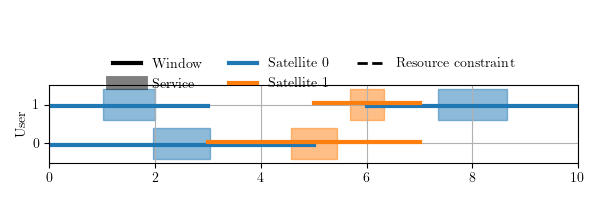

In [268]:
reset_id_counters()
requests = [
    Request(usr_id=0, ts=0.0, te=10.0, dur=2.0, ta=3.0),
    Request(usr_id=1, ts=3.0, te=10.0, dur=3.0, ta=0.0),
    Request(usr_id=1, ts=8.0, te=10.0, dur=2.0, ta=2.0),
]
request_dict = {r.id: r for r in requests}

service_windows = [
    # Satellite 0
    ServiceWindow(usr_id=0, sat_id=0, ts=0.0, te=5.0),
    ServiceWindow(usr_id=1, sat_id=0, ts=0.0, te=3.0),
    ServiceWindow(usr_id=1, sat_id=0, ts=6.0, te=10.0),
    # Satellite 1
    ServiceWindow(usr_id=0, sat_id=1, ts=3.0, te=7.0),
    ServiceWindow(usr_id=1, sat_id=1, ts=5.0, te=7.0),
]

N_sat = 2
N_usr = 2
N_req = len(requests)
N_win = len(service_windows)

transition_times = np.ones((len(service_windows), len(service_windows)))
transition_times = np.ones((N_sat, N_req, N_req))
for i in range(N_sat):
    transition_times[i, np.diag_indices(N_req)] = 0
transition_times[0, :] = 0
transition_times[:, 0] = 0


t_step = 1
t_final = 10
N_steps = int(t_final / t_step)
CN0 = np.ones((2, N_usr, N_steps))

data_gen = -0.2 * np.ones((N_sat, N_steps))
energy_gen = 0.2 * np.ones((N_sat, N_steps))

problem = PntSchedulingProblem(
    t_step=t_step,
    t_final=t_final,
    requests=requests,
    service_windows=service_windows,
    transition_times=transition_times,
    CN0=CN0,
    max_energy=2 / 0.2,
    min_energy=2,
    max_data=8,
    min_data=8 / 0.8 * 0.2,
    payload_data_gen=1,
    payload_energy_gen=-1,
    energy_gen=energy_gen,
    data_gen=data_gen,
)
problem.set_contrained(True)


fig, ax = plt.subplots(1, 1, figsize=(6, 2))
plotting.plot_requests_service_windows(requests, service_windows, ax=ax)
plt.tight_layout()

# Debug

In [566]:
seed = 0
params = dict(d=6, gamma=0.7, N_max=5, dur_min=1)
solver = SmdpForwardSearchSolver(problem)

In [567]:
from util import timed, get_metrics
np.random.seed(seed)

old_policy = None
problem.set_current_policy(None)

policies, metrics = [], []
arrival_times = problem.get_arrival_times()
for ta in arrival_times:
    # Set current time and policy
    problem.set_current_time(ta)
    if old_policy is not None:
        problem.set_current_policy(old_policy)

    # Solve
    s = problem.initial_state()
    policy, time = timed(solver.solve, s, **params)
    policy = policy if old_policy is None else problem.merge_policies(policy)
    metric = get_metrics(problem, policy, time, gamma=1)
    metric["params"] = params
    old_policy = policy

    policies.append(policy)
    metrics.append(metric)

In [550]:
ta = arrival_times[2]
problem.set_current_time(ta)
problem.set_current_policy(policy)

In [555]:
s0 = problem.initial_state()
actions = problem.available_actions(s0, N_max=5, dur_min=1)
a0 = actions[0]
s0, actions, a0

(State(t=[3. 3.], D=[7.4 5. ], E=[3.6 6. ], req=[1, None], req_times=[0.0, 3.0, 2.0]),
 [Action(sat=0, usr=None, req=None, ts=3.00, dur=1.00),
  Action(sat=0, usr=0, req=0, ts=4.00, dur=1.00)],
 Action(sat=0, usr=None, req=None, ts=3.00, dur=1.00))

In [556]:
s1 = problem.transition_function(s0, a0)
actions = problem.available_actions(s1, N_max=5, dur_min=1)
a1 = actions[1]
s1, actions, a1

(State(t=[4. 3.], D=[7.2 5. ], E=[3.8 6. ], req=[None, None], req_times=[0.0, 3.0, 2.0]),
 [Action(sat=1, usr=None, req=None, ts=3.00, dur=1.00),
  Action(sat=1, usr=0, req=0, ts=3.00, dur=1.00)],
 Action(sat=1, usr=0, req=0, ts=3.00, dur=1.00))

In [557]:
s2 = problem.transition_function(s1, a1)
actions = problem.available_actions(s2, N_max=5, dur_min=1)
a2 = actions[1]
s2, actions, a2

(State(t=[4. 4.], D=[7.2 5.8], E=[3.8 5.2], req=[None, 0], req_times=[1.0, 3.0, 2.0]),
 [Action(sat=0, usr=None, req=None, ts=4.00, dur=1.00),
  Action(sat=0, usr=0, req=0, ts=4.00, dur=1.00)],
 Action(sat=0, usr=0, req=0, ts=4.00, dur=1.00))

In [559]:
s3 = problem.transition_function(s2, a2)
actions = problem.available_actions(s3, N_max=5, dur_min=1)
a3 = actions[0]
s3, actions, a3

(State(t=[5. 4.], D=[8.  5.8], E=[3.  5.2], req=[0, 0], req_times=[2.0, 3.0, 2.0]),
 [Action(sat=1, usr=None, req=None, ts=4.00, dur=1.00)],
 Action(sat=1, usr=None, req=None, ts=4.00, dur=1.00))

In [560]:
policy, time = timed(solver.solve, s, **params)

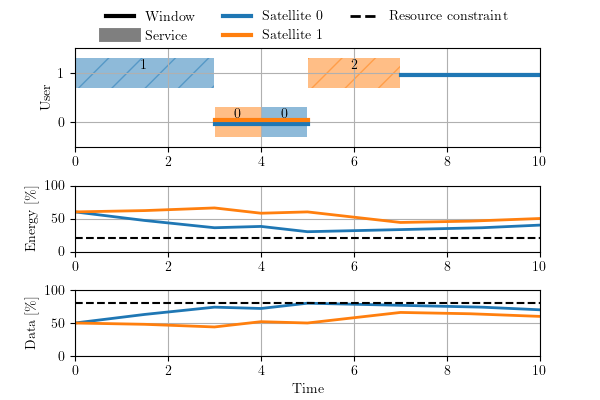

In [569]:
if len(policies) > 1:
    old_policy, policy = policies[-2:]
else:
    old_policy = None
    policy = policies[-1]

gridspec_kw = dict(hspace=0.5, height_ratios=[1.5, 1, 1])
fig, axs = plt.subplots(3, 1, figsize=(6, 4), gridspec_kw=gridspec_kw)
plotting.plot_requests_service_windows(
    requests, problem.constr_windows, policy, ax=axs[0], old_policy=old_policy
)
plotting.plot_resources(problem, policy, ax=axs[1:])
# plt.tight_layout()
plt.show()

# Solve

In [570]:
import util

seed = 0
problem.constr = True
fs_params = dict(d=6, gamma=0.7, N_max=5, dur_min=1)
solver = SmdpForwardSearchSolver
metrics, policies = util.solve_online(fs_params, problem, solver, seed, return_all=True)
pp.pprint(metrics[-1])

{'params': {'N_max': 5, 'd': 6, 'dur_min': 1, 'gamma': 0.7},
 'reward': 8.2438,
 'time': 0.04929,
 'total': 100.0,
 'user': [100.0, 100.0, 100.0]}


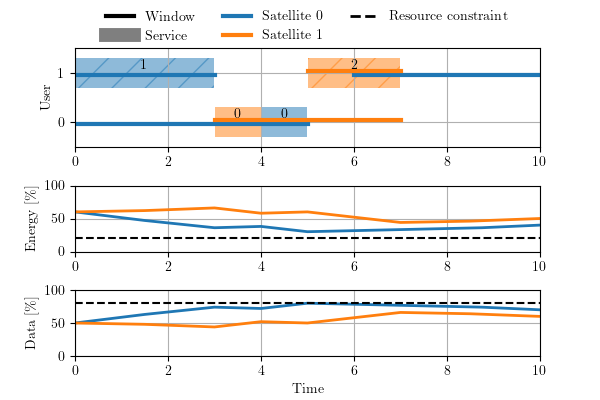

In [571]:
if len(policies) > 1:
    old_policy, policy = policies[-2:]
else:
    old_policy = None
    policy = policies[-1]

gridspec_kw = dict(hspace=0.5, height_ratios=[1.5, 1, 1])
fig, axs = plt.subplots(3, 1, figsize=(6, 4), gridspec_kw=gridspec_kw)
plotting.plot_requests_service_windows(
    requests, service_windows, policy, ax=axs[0], old_policy=old_policy
)
plotting.plot_resources(problem, policy, ax=axs[1:])
# plt.tight_layout()
plt.show()

In [572]:
import util

seed = 0
problem.set_contrained(True)
mcts_params = dict(d=5, gamma=0.7, n=100, c=5, N_max=5, dur_min=1)
solver = SmdpMctsSolver
metrics, policies = util.solve_online(mcts_params, problem, solver, seed, return_all=True)
pp.pprint(metrics[-1])

{'params': {'N_max': 5, 'c': 5, 'd': 5, 'dur_min': 1, 'gamma': 0.7, 'n': 100},
 'reward': 8.2438,
 'time': 1.93309,
 'total': 100.0,
 'user': [100.0, 100.0, 100.0]}


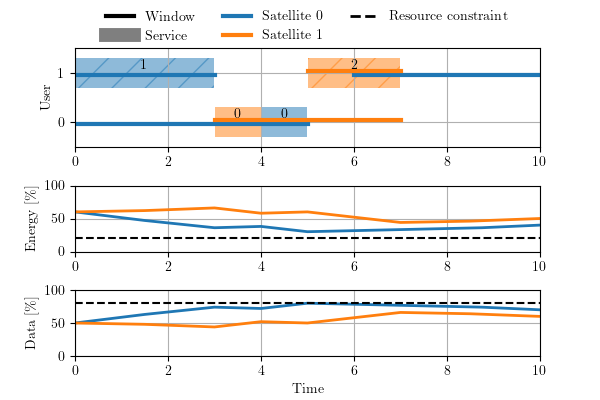

In [573]:
if len(policies) > 1:
    old_policy, policy = policies[-2:]
else:
    old_policy = None
    policy = policies[-1]

gridspec_kw = dict(hspace=0.5, height_ratios=[1.5, 1, 1])
fig, axs = plt.subplots(3, 1, figsize=(6, 4), gridspec_kw=gridspec_kw)
plotting.plot_requests_service_windows(
    requests, service_windows, policy, ax=axs[0], old_policy=old_policy
)
plotting.plot_resources(problem, policy, ax=axs[1:])
# plt.tight_layout()
plt.show()

In [574]:
from copy import deepcopy
problem1 = deepcopy(problem)
problem1.set_current_policy(None)

In [575]:
import util

seed = 0
np.random.seed(seed)
problem.set_contrained(True)
ilp_params = dict(time_step_factor=1)
solver = DiscreteTimeIpSolver
metrics, policies = util.solve_online(ilp_params, problem, solver, seed, return_all=True)
pp.pprint(metrics[-1])

                                     CVXPY                                     
                                     v1.4.2                                    
(CVXPY) Apr 24 11:02:21 PM: Your problem has 60 variables, 177 constraints, and 0 parameters.
(CVXPY) Apr 24 11:02:21 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 24 11:02:21 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 24 11:02:21 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 24 11:02:21 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Apr 24 11:02:21 PM: Compiling problem (target solver=GUROBI).


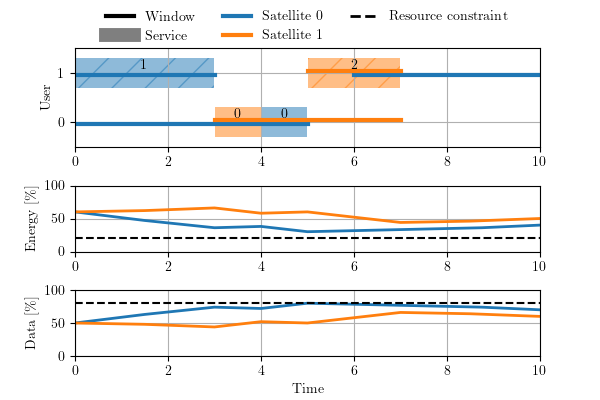

In [576]:
if len(policies) > 1:
    old_policy, policy = policies[-2:]
else:
    old_policy = None
    policy = policies[-1]

gridspec_kw = dict(hspace=0.5, height_ratios=[1.5, 1, 1])
fig, axs = plt.subplots(3, 1, figsize=(6, 4), gridspec_kw=gridspec_kw)
plotting.plot_requests_service_windows(
    requests, service_windows, policy, ax=axs[0], old_policy=old_policy
)
plotting.plot_resources(problem, policy, ax=axs[1:])
# plt.tight_layout()
plt.show()